##Installation

In [ ]:
#install before running

import numpy as np
import pandas as pd
#import pdflatex

import matplotlib.pyplot as plt
#from mpl_toolkits import mplot3d
import matplotlib.gridspec as gridspec
#from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib import cm
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines

from scipy.ndimage import median_filter,generic_filter
import scipy.ndimage as sc


from scipy.interpolate import splrep, BSpline
from scipy.interpolate import UnivariateSpline
from scipy import interpolate
from scipy import optimize
import scipy.interpolate as sci

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from matplotlib.legend_handler import HandlerLine2D, HandlerTuple
from matplotlib.legend_handler import HandlerBase
#from matplotlib import collections

from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

#import ot
from sklearn.neighbors import KernelDensity
import numpy.random as npr
import scipy.stats as stats


##Laundauer model

###KL DIVERGENCE
Functions for the predicted cumulants and corrections for the marginal density of the position and the optimal protocol.

In [1]:


df = pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/kl_underdamped_v13.csv"))#pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/overdamped_kl_results_v10.csv"))
#

#fill infs and nans with zeros
df.replace(np.inf, 0, inplace=True)
df.replace(np.nan, 0, inplace=True)


##PARAMETERS
Tf = 5 #2#4
epsilon = 0.2

g = 0
omega = 1
beta = 1

#decimal places for the time lookup.
dps =  6#
filter_delta = 20 #size of convolution filter to use

#tolerance to zero.
tol = 1e-10

#constants
def B_fn(Tf):
  return -((1+g)/Tf)*np.tanh(omega*Tf/2)*(omega*np.tanh(Tf) - 2*np.tanh(omega*Tf/2))/(omega*np.tanh(omega*Tf/2) - 2*np.tanh(Tf))

def A_fn(Tf):
  return (1+g)*(1 - (((omega**2 - 4)*(np.tanh(omega*Tf/2)*np.tanh(Tf)))/(omega*Tf*(omega*np.tanh(omega*Tf/2)-2*np.tanh(Tf)))))

T = Tf
A_minus_B = (1+g)*(1-((2/(omega*T))*(np.tanh(omega*T/2))))

A = A_fn(Tf)
B = B_fn(Tf)

alpha = np.sqrt((1+g)*A)

#clips values close to zero to prevent errors in logarithms
def zchop(a,tol = tol):
  #input: vector a
  #output: vector with values close to zero clipped.
  a[np.abs(a) < tol] = 0.0
  return a

#get values of t2
t2_vec = np.array(df.t.unique())
t2_vec.sort()

xmin = -5
xmax = 5

#get qaxis
q_axis = df[df.t == 0].x.to_numpy()

#exact boundary conds
p_initial = np.exp(-(q_axis-1)**4/4)
p_final = np.exp(-(((q_axis**2 - 1)**2))/4)
pi_norm = np.abs(np.trapz(p_initial,q_axis))
pf_norm = np.abs(np.trapz(p_final,q_axis))

#generate vecotr of t0 from values of t2
times_t0 = np.round(t2_vec/(epsilon**2),dps)


In [ ]:
#cut the x-axis so that each is of the same length.
#This should only remove where there is no mass, ie rho = 0

for t2 in t2_vec:
  xmin = np.maximum(xmin,np.min(df[df.t==t2].x))
  xmax = np.minimum(xmax,np.max(df[df.t==t2].x))

#delete edge rows
df.drop(df[df.x < xmin].index, inplace=True)
df.drop(df[df.x > xmax].index, inplace=True)



In [ ]:

#compute mean and variance using all data
mean_0 = np.zeros(len(t2_vec))
var_0 = np.zeros(len(t2_vec))

for t2 in enumerate(t2_vec):
  #get q-axis
  q_temp = df[df.t == t2[1]].x.to_numpy()
  #get rho
  rho_temp = df[df.t == t2[1]].rho.to_numpy()
  #compute first order mean and var as functions of t2
  mean_0[t2[0]] = np.trapz(q_temp*rho_temp,q_temp)
  var_0[t2[0]] = np.trapz((q_temp**2)*rho_temp,q_temp)


In [ ]:


#get qaxis
q_axis = df[df.t == 0].x.to_numpy()

#generate vecotr of t0 from values of t2
times_t0 = np.round(t2_vec/(epsilon**2),dps)

#function to get rho at time t0.
def rho(t0):
  t2 = round(t0*(epsilon**2),dps)
  rho_temp = df[df.t==t2].rho.to_numpy()
  return zchop(rho_temp)

#get all xcoords where there is probability mass
def get_rhomask(t0):
  return np.where(rho(t0)>0)


#function to get sigma
def sigma(t0):

  t2 = round(t0*(epsilon**2),dps)
  sigtemp = df[df.t==t2].sigma.to_numpy()

  return sigtemp


In [ ]:

def b(t0,g=0):
  omega = 1#np.sqrt((1+g)/g)

  denom1 =np.cosh(T)*np.sinh(omega*T) -(2*np.sinh(T)*np.cosh(omega*T)+2*np.sinh(T))/omega

  num3 = np.sinh(omega*(T-t0))*np.exp(-T)
  num4 = np.sinh(omega*t0)*np.exp(T) - np.sinh(omega*T)*np.exp(2*t0 - T)
  return (1/denom1)*(num3+num4)

def a_minus_b2(t0,g=0):
  omega = 1#np.sqrt((1+g)/g)

  return 1 -(np.cosh(omega*t0)+np.cosh(omega*(t0-T)))/(1+np.cosh(T*omega))

def a(t0,g=0):

  return a_minus_b2(t0,g) + b(t0,g)

def b_dot(t0,g=0):
  omega = 1#np.sqrt((1+g)/g)

  denom1 =np.cosh(T)*np.sinh(omega*T) -(2*np.sinh(T)*np.cosh(omega*T)+2*np.sinh(T))/omega

  num3 = -omega*np.cosh(omega*(T-t0))*np.exp(-T)
  num4 = omega*np.cosh(omega*t0)*np.exp(T) - 2*np.sinh(omega*T)*np.exp(2*t0 - T)
  return (1/denom1)*(num3+num4)
  """
  omega = np.sqrt((1+g)/g)

  denom1 = omega*np.cosh(T) - 2*(np.sinh(T)/np.tanh(omega*T/2))
  denom2 = np.sinh(omega*T)

  num1 = omega*np.sinh(omega*t0) - 2*np.exp(2*t0)
  num2 = omega*(np.exp(2*T) - np.cosh(omega*T))*np.cosh(omega*t0)

  return omega*np.exp(-T)*((num1/denom1) + (num2/denom1)/denom2)
  """

def a_dot(t0,g=0):
  omega = 1#np.sqrt((1+g)/g)

  term1 = -(np.sinh(omega*t0)+np.sinh(omega*(t0-T)))/(1+np.cosh(T*omega))

  return b_dot(t0,g) + omega*term1

#mean and variances
def mean_t0(t0):

  t2 = round(t0*(epsilon**2),dps)
  index_mean = np.where(t2_vec==t2)[0][0]

  return mean_0[index_mean]

def var_t0(t0):

  t2 = round(t0*(epsilon**2),dps)
  index_mean = np.where(t2_vec==t2)[0][0]

  return var_0[index_mean]


In [ ]:
#derivative functions
def dsigma(t0):
  sigma_temp = sigma(t0)
  idx = get_rhomask(t0)

  sigma_vals = sigma_temp[idx]
  q_vals = q_axis[idx]

  dsig = np.gradient(sigma_vals,q_vals)
  dsigout = generic_filter(dsig,sc.median,filter_delta,mode = "nearest")

  dtemp = np.zeros(len(q_axis))
  dtemp[idx] = dsigout

  return dtemp

def kappa(t0): #mu dot 1
  integral = rho(t0) * dsigma(t0)
  return -np.trapz(integral,q_axis)

def dfun(vals,qs):

  dfun = np.gradient(vals,qs)

  return generic_filter(dfun,sc.median,40,mode = "nearest")

def dlogrho(t0):
  logrho = np.log(rho(t0))

  #get rid of nans
  #interpolate only on non-zero vals of rho
  idx = get_rhomask(t0)
  logrho_temp = logrho[idx]
  q_axis_temp = q_axis[idx]

  #differentiate and filter without edges
  dlogrho = np.gradient(logrho_temp,q_axis_temp)
  filter_dlogrho = generic_filter(dlogrho,
                 sc.median,filter_delta,mode="nearest")

  #put back into right place
  dlogout = np.zeros(len(q_axis))
  dlogout[idx] = filter_dlogrho

  return dlogout

def drho(t0):
  rho_vals = rho(t0)

  #interpolate only on non-zero vals of rho
  idx = get_rhomask(t0)
  rho_vals_temp = rho_vals[idx]
  q_axis_temp = q_axis[idx]

  drho = np.gradient(rho_vals_temp,q_axis_temp)
  #set values outside of range to zero to prevent extrapolation error
  drho_vals = np.zeros(len(q_axis))
  drho_vals[idx] = generic_filter(drho,sc.median,filter_delta,mode="constant")

  return drho_vals

def rho_dsigma_alpha_rho(t0):

  rho_dsigma_alpha_rho = rho(t0)*dsigma(t0) + alpha*drho(t0)

  #fill nan with zero
  rho_dsigma_alpha_rho[np.isnan(rho_dsigma_alpha_rho)] = 0

  return rho_dsigma_alpha_rho

def dsigma_alpha_rho(t0):

  dsigma_alpha_rho = dsigma(t0) + alpha*dlogrho(t0)

  #fill nan with zero
  dsigma_alpha_rho[np.isnan(dsigma_alpha_rho)] = 0

  return dsigma_alpha_rho

def rho_ddsigma_alpha_rho(t0):

  #get drho
  drhotemp = dlogrho(t0)

  #remove zeros first
  idx = get_rhomask(t0)
  ddrhotemp = drhotemp[idx]
  q_temp = q_axis[idx]
  ddlogrho = np.gradient(ddrhotemp,q_temp)

  ddlogrho = generic_filter(ddlogrho,sc.mean,filter_delta,mode="nearest")

  #get ddsigma
  dsigtemp = dsigma(t0)
  dsig_vals = dsigtemp[idx]
  ddsigtemp = np.gradient(dsig_vals,q_temp)
  #dfun(dsigtemp,q_axis)
  #ddsig_add = ddsigtemp[~np.isnan(drhotemp)]

  temp_out = alpha*ddlogrho + generic_filter(ddsigtemp,sc.mean,filter_delta,mode="nearest")

  temp_vals_out = np.zeros(len(q_axis))
  temp_vals_out[idx] = temp_out

  output_vals = temp_vals_out*rho(t0)
  return generic_filter(output_vals,sc.mean,size=filter_delta,mode="constant")

In [ ]:

##
def f11(t0):

  coeff1 = -a(t0)/A
  num1 = rho_dsigma_alpha_rho(t0)

  coeff2 = rho(t0) *(B*a(t0) - A*b(t0))/(A*A_minus_B)
   #(A-B))

  return coeff1*num1 + coeff2*kappa(t0)

##
def calculate_df11(t0):
  drho_vals = drho(t0)

  coeff1 = -a(t0)/A
  num1 = (drho_vals*dsigma_alpha_rho(t0)) + rho_ddsigma_alpha_rho(t0)

  num1[np.isnan(num1)] = 0
  num1[np.isinf(num1)] = 0

  coeff2 = (B*a(t0) - A*b(t0))/(A*A_minus_B)

  df11_out = coeff1*num1 + coeff2*(kappa(t0)*drho_vals)

  return df11_out


In [ ]:

#coefficients of the gradient of df11
def coeff1_df11(t0):
  coeff1 = -a(t0)/A
  return coeff1

def coeff2_df11(t0):
  coeff2 = (B*a(t0) - A*b(t0))/(A*A_minus_B)
  return coeff2

#compute f02 at t0 and fixed t2.
def f02_new(t0,g=g,T=T):

  #fetch the constants in t2
  t2_term1 = drho(t0)*dsigma_alpha_rho(t0) + rho_ddsigma_alpha_rho(t0)
  t2_termrho = drho(t0)*kappa(t0)

  term1 = -g*(coeff1_df11(t0)*t2_term1 + coeff2_df11(t0)*t2_termrho)

  int_limit = np.where(times_t0==t0)[0][0] + 1
  coeff1_df11_temp = [coeff1_df11(t)*t2_term1 for t in times_t0]
  coeff2_df11_temp = [coeff2_df11(t)*t2_termrho for t in times_t0]

  coeff1_int1 = (t0/T)*np.trapz(coeff1_df11_temp,times_t0,axis=0)
  coeff2_int1 = (t0/T)*np.trapz(coeff2_df11_temp,times_t0,axis=0)

  coeff1_int2 = np.trapz(coeff1_df11_temp[0:int_limit],times_t0[0:int_limit],axis=0)
  coeff2_int2 = np.trapz(coeff2_df11_temp[0:int_limit],times_t0[0:int_limit],axis=0)

  return term1 + (1+g)*(coeff1_int1 + coeff2_int1 - (coeff1_int2 + coeff2_int2))


In [ ]:
def calculate_distribution(t0):
  rvals = rho(t0)+ (epsilon**2)*f02_new(t0)

  #find normalising factor
  norm_factor = np.trapz(rvals,q_axis)

  return rvals / norm_factor

def calculate_optimal_drift(t0):

  coeff1 = (a_dot(t0) + a(t0))/A

  dlog_rho = dlogrho(t0)

  term1 = (alpha*coeff1 - 1)*dlog_rho
  term2 = coeff1*dsigma(t0)

  coeff3 = kappa(t0)/(A*(A-B))
  term3 = (B*a_dot(t0) - A*b_dot(t0)) + (B*a(t0) - A*b(t0))
  opt_drift = term1 + term2 - coeff3*term3

  opt_drift[np.isnan(opt_drift)] = 0
  opt_drift[np.isinf(opt_drift)] = 0

  return -opt_drift


In [ ]:
#compute the pdfs and drifts for each t0 and adds them to the dataframe
df['UDpdf'] = np.ones(len(df))
df['UDdrift'] = np.ones(len(df))
df['smooth_UDpdf'] = np.ones(len(df))

for t0 in times_t0:
  t2 = round(t0*(epsilon**2),dps)
  print(t0)
  new_vals = calculate_distribution(t0)
  smooth_dist = generic_filter(new_vals,sc.mean,100,mode="constant")
  drift_vals = calculate_optimal_drift(t0)
  df.loc[df[df.t==t2].index,"UDpdf"] = new_vals
  df.loc[df[df.t==t2].index,"UDdrift"] = drift_vals
  df.loc[df[df.t==t2].index,"smooth_UDpdf"] = smooth_dist

#function to get sigma
def distribution(t0):
  t2 = round(t0*(epsilon**2),dps)
  dist = df[df.t==t2].UDpdf.to_numpy()
  return dist

#function to get sigma
def optimal_drift(t0):
  t2 = round(t0*(epsilon**2),dps)
  drift_temp = df[df.t==t2].UDdrift.to_numpy()
  return drift_temp


#function to get sigma
def smooth_distribution(t0):
  t2 = round(t0*(epsilon**2),dps)
  drift_temp = df[df.t==t2].smooth_UDpdf.to_numpy()
  return drift_temp


In [ ]:
df.drop(["UDpdf"], axis=1, inplace=True)
df.rename(columns={"smooth_UDpdf": "UDpdf"},inplace=True)


df.to_csv('drive/MyDrive/Colab Notebooks/kl_underdamped_v13.csv',index=False)


###Plots

In [ ]:
##make the plots

titlepad = 5
titlex = 0.15
titley = 0.85
titlezorder = 1000
titles = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)","(i)","(j)","(k)","(l)","(m)","(n)","(o)","(p)","(q)"]
time_titles = ["$\mathrm{t} = 0$","$\mathrm{t} = 0.25\mathrm{t}_f$",
               "$\mathrm{t} = 0.4\mathrm{t}_f$","$\mathrm{t} = 0.5\mathrm{t}_f$",
               "$\mathrm{t} = 0.6\mathrm{t}_f$","$\mathrm{t} = 0.7\mathrm{t}_f$",
               "$\mathrm{t} = 0.8\mathrm{t}_f$","$\mathrm{t} = 0.95\mathrm{t}_f$",
               "$\mathrm{t} = \mathrm{t}_f$"]

#dist title location
disttitlex = -2.8
disttitley = 0.52

suptitlex = 0.07
suptitley = 1.1

dashlinezorder = 10

#alpha for filled shapes
shadingalpha = 1

# Plotting the graphs)
#COLORS
c2 = "#a6cee3" #lightblue
c3 = "orange" #"#33a02c" #dark green
c1 = "#1f78b4" #darkblue
c4 = "#b2df8a" #light green


#set ylim for plot
ymin = -30
ymax = 20

#xlims
xlimmax = 3
xlimmin = -3

lw = 3

#fontsizes
xmax = 5
fontsize = 22
fontsizeticks = 18
fontsizetitles = 22

#Cumulant plots parameters
#df = pd.read_csv("kl_gauss_T2_v8.csv")


####KL gauss
fontsize = 22
fontsizeticks = 18
fontsizetitles = 22

titlepad = 10
xtitle = 0.07
ytitle = 0.88
titlezorder = 1000


lw = 3

# Data for the graphs
#x = df.t
titlepad = 5
def format_axes(ax,fontsize):

  ax.set_xlim((0,T))
  ax.set_xlabel(r"$\mathrm{t}$",fontsize = fontsizetitles)

  #ax.set_xticklabels(labels = [0,1,2,3,4,5],fontsize=10)
  ax.tick_params(axis='y', labelsize=fontsizeticks)
  ax.tick_params(axis='x', labelsize=fontsizeticks)
  return ax

def format_drift(ax):

  #ax.yaxis.tick_right()
  ax.tick_params(axis='x', labelsize=fontsizeticks)
  ax.tick_params(axis='y', labelsize=fontsizeticks)

  ax.set_ylim((-30,30))
  ax.set_xlim((xlimmin,xlimmax))
  ax.set_xlabel(r"$\mathrm{q}$",fontsize= fontsize,labelpad=7)

##plot set-up
def format_dist_axes(ax):

  #ax.patch.set_alpha(0)
  #ax.yaxis.tick_right()
  ax.tick_params(axis='x', labelsize=fontsizeticks)
  ax.tick_params(axis='y', labelsize=fontsizeticks)
  #ax.tick_params(labeltop='off', labelright='off')

  #ax.set_ylim((-0.01,0.65))
  ax.set_xlim((xlimmin,xlimmax))
  ax.spines['bottom'].set_zorder(1000)

  #ax.set_xticks([])
  #ax.set_xticklabels([])
  #ax.set_xlabel(r"$\mathrm{q}$",fontsize= fontsize)



##plot set-up
def format_scatter_axes(ax):

  ax.set_xlim((-4,3))
  ax.set_ylim((-3,3))

  ax.tick_params(axis='both', labelsize=fontsizeticks)

def cleaner(arr,t0):

  #masks nans and infs and returns a pair for plotting
  #copy q axis
  plotq = np.copy(q_axis)

  masknan = get_rhomask(t0)

  #this function removes nan's and the end points which come from the truncation of the gradients
  arr = arr[np.min(masknan)+20:np.max(masknan)-20]
  plotq = plotq[np.min(masknan)+20:np.max(masknan)-20]

  return plotq, arr
  #generic_filter(arr,sc.median,1,mode="constant")




In [ ]:
#plot params


def plot_pdf_nucleation(tcurr,title,labels,loc):
  '''This functions plots a distribution and labels it

  input:
  -tcurr: the time in terms of t0 to plot
  -title: title of the graph (if using)
  -label: label of the panel
  -loc: location as a matplotlib subplot code (or gridspec)

  output:
  -plot in location given by loc with the overdamped(in orange)
  and underdamped (in blue) of the marginal density of the position
  '''

  # t0 distribution
  plt.subplot(loc)
  plt.title(title, loc = "center", fontsize=fontsizetitles)

  plt.plot(q_axis,rho(tcurr),color="orange",lw=4)
  plt.plot(q_axis,distribution(tcurr),color=c1,lw=3,  label =r"$\mathrm{t} = 0$",zorder = 10000)

  ax = plt.gca()
  format_dist_axes(ax)
  #ax.text(s = labels[0],fontweight ="bold",fontsize = fontsizetitles,x = disttitlex, y =disttitley,zorder = titlezorder)

  #ax.set_xticklabels([])
  ax.tick_params(axis='y', labelsize=fontsizeticks)


In [ ]:
plt.figure(figsize=(15,6))
plot_pdf_nucleation(0,"$\mathrm{t} = 0$",None,151)
ax0 = plt.gca()
ax0.fill_between(q_axis,p_initial/pi_norm,color = c2,alpha = shadingalpha)

plot_pdf_nucleation(0.5*T,"$\mathrm{t} = 0.5\ \mathrm{t}_{\mathrm{f}}$",None,152)
ax1 = plt.gca()
ax1.set_yticklabels([])
plot_pdf_nucleation(0.7*T,"$\mathrm{t} = 0.7\ \mathrm{t}_{\mathrm{f}}$",None,153)
ax1 = plt.gca()
ax1.set_yticklabels([])
plot_pdf_nucleation(0.85*T,"$\mathrm{t} = 0.85\ \mathrm{t}_{\mathrm{f}}$",None,154)
ax1 = plt.gca()
ax1.set_yticklabels([])
plot_pdf_nucleation(T,"$\mathrm{t} = \mathrm{t}_{\mathrm{f}}$",None,155)

plt.tight_layout()
ax = plt.gca()
ax.fill_between(q_axis,p_final/pf_norm,color = c2,alpha = shadingalpha)
ax.set_yticklabels([])

#make legend
l0 = mlines.Line2D([], [], color=c1, lw = lw)
l1 = mlines.Line2D([], [], color="orange", lw = lw)
p0 = mpatches.Patch(color = c2, alpha=shadingalpha)

ax.legend([l0,l1,p0],["Underdamped","Overdamped","Assigned Boundary Conditions"],
              prop = {"size": fontsizetitles },
              ncol = 4,
              bbox_to_anchor=(-4.8, -0.05),
              frameon = False)


plt.savefig("KL_LAND_PDFS.png")
#plt.savefig("KL_LAND_PDFS.pdf", format="pdf")
#plt.savefig("test1.eps", format="eps")

plt.close()

In [ ]:
#plot params

#fontsizes
xmax = 5
fontsize = 28
fontsizeticks = 22
fontsizetitles = 28

#set ylim for plot
ymin = -30
ymax = 30

def plot_pair(tcurr,title,labels,gs,locy):
  # t0 distribution
  plt.subplot(gs[0,locy])
  plt.title(title, loc = "center", fontsize=fontsizetitles)

  plt.plot(q_axis,rho(tcurr),color=c3,lw=4)
  plt.plot(q_axis,distribution(tcurr),color=c1,lw=3, label =r"$\mathrm{t} = 0$",zorder = 10000)

  #plt.plot(q_axis,rho(tcurr),color=c3,lw=4)
  #plt.plot(q_axis,generic_filter(distribution(tcurr),sc.mean,100,mode="constant"),color=c1,lw=3,  label =r"$\mathrm{t} = 0$",zorder = 10000)


  ax = plt.gca()
  format_dist_axes(ax)
  ax.text(s = labels[0],fontsize = fontsizetitles,x = disttitlex, y =disttitley,zorder = titlezorder)

  ax.set_xticklabels([])
  ax.tick_params(axis='y', labelsize=fontsizeticks)

  drift0 = plt.subplot(gs[1, locy])
  plot_data = cleaner(optimal_drift(tcurr),tcurr)

  #this just removes the areas of low statistics rho < tol
  qseries = plot_data[0]
  yseries = plot_data[1]
  sigma_data = cleaner(dsigma(tcurr),tcurr)
  sigmaseries = -sigma_data[1]

  ax0 = plt.gca()
  format_drift(ax0)
  ax0.text(s = labels[1],fontsize = fontsizetitles,x = disttitlex, y =25, zorder = titlezorder)

  #series1a, = ax0.plot(qseries,yseries,color = c1,lw=lw,label = r"Underdamped",alpha=0.5,zorder = 100)
  #series1b, = ax0.plot(qseries,sigmaseries,color = c3,lw=lw,label = r"Overdamped",alpha=0.5)
  series1c, = ax0.plot(qseries,generic_filter(yseries,sc.mean,100,mode="nearest"),color = c1,lw=lw,label = r"Underdamped",zorder = 10000)
  series1d, = ax0.plot(qseries,generic_filter(sigmaseries,sc.mean,100,mode="nearest"),color = c3,lw=lw,label = r"Underdamped",zorder = 10000)

  if locy ==0:
    ax.set_ylabel(r'$\mathrm{f}_{\mathrm{t}}(\mathrm{q})$',fontsize = fontsizetitles,labelpad= 7)
    ax0.set_ylabel(r'$-\partial U_{\mathrm{t}}(\mathrm{q})$',fontsize = fontsizetitles,labelpad= -5)
    if gs == gs0:
      #for edges
      ax.fill_between(q_axis,p_initial/pi_norm,color = c2,alpha = shadingalpha)
  else:
    ax0.set_yticklabels([])
    ax.set_yticklabels([])

  if locy ==-1 and gs == gs1:
    ax.fill_between(q_axis,p_final/pf_norm,color = c2,alpha = shadingalpha)


In [ ]:

#set up the gridspec

fig = plt.figure(figsize = (18,24)) #figsize = (width,height)

gs = gridspec.GridSpec(2, 1, height_ratios=[1,1],hspace=0.2)
gs0 = gridspec.GridSpecFromSubplotSpec(2, 5, height_ratios=[1,2], subplot_spec=gs[0], hspace=0.1, wspace=0.05)
gs1 = gridspec.GridSpecFromSubplotSpec(2, 5, height_ratios=[1,2], subplot_spec=gs[1], hspace=0.1, wspace=0.05)

plot_pair(0,"$\mathrm{t} = 0$",["(a)","(f)"],gs0,0)
plot_pair(0.25*T,"$\mathrm{t} = 0.25\ \mathrm{t}_f$",["(b)","(g)"],gs0,1)
plot_pair(0.5*T,"$\mathrm{t} = 0.5\ \mathrm{t}_f$",["(c)","(h)"],gs0,2)
plot_pair(0.6*T,"$\mathrm{t} = 0.6\ \mathrm{t}_f$",["(d)","(i)"],gs0,3)
plot_pair(0.7*T,"$\mathrm{t} = 0.7\ \mathrm{t}_f$",["(e)","(j)"],gs0,-1)

plot_pair(0.8*T,"$\mathrm{t} = 0.8\ \mathrm{t}_f$",["(k)","(p)"],gs1,0)
plot_pair(0.85*T,"$\mathrm{t} = 0.85\ \mathrm{t}_f$",["(l)","(q)"],gs1,1)
plot_pair(0.9*T,"$\mathrm{t} = 0.9\ \mathrm{t}_f$",["(m)","(r)"],gs1,2)
plot_pair(0.95*T,"$\mathrm{t} = 0.95\ \mathrm{t}_f$",["(n)","(s)"],gs1,3)
plot_pair(T,"$\mathrm{t} = \mathrm{t}_f$",["(o)","(t)"],gs1,-1)

#make legend
l0 = mlines.Line2D([], [], color=c1, lw = lw)
l1 = mlines.Line2D([], [], color=c3, lw = lw)
p0 = mpatches.Patch(color = c2, alpha=shadingalpha)

plt.legend([l0,l1,p0],["Underdamped","Overdamped","Assigned Boundary Conditions"],
              prop = {"size": fontsizeticks },
              ncol = 3,
              bbox_to_anchor=(0.4, -0.1),
              frameon = False)


#plt.savefig("kl_land_drift_v38.eps")
#plt.savefig("kl_land_drift_v38.pdf")
plt.savefig("kl_land_drift_v39.png")
plt.close()

###cumulants

In [ ]:
df_kl_cumulants = pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/kl_cumulants_v2.csv"))


In [ ]:


def conditional_mom_mean(t0): ##conditional momentum mean E(p|q)
  return epsilon*f11(t0)

def mom_mean(t0):
  return epsilon*(a(t0)-b(t0))*kappa(t0)/A_minus_B

#correction to the position marginal distribution
def pos_correction(t0):
  return rho(t0) + f02_new(t0)*(epsilon**2)

#linear position cumulant
#position mean
def linear_position_cumulant(t0):
  term1 = mean_t0(t0) + kappa(t0)*(epsilon**2)*g*(a(t0)-b(t0))/(A-B)
  coeff2 = (epsilon**2)*(1+g)*kappa(t0)/(A-B)
  int_limit = np.where(times_t0==t0)[0][0] + 1
  ab_temp = [a(t)-b(t) for t in times_t0]
  int1 = (t0/Tf)*np.trapz(ab_temp,times_t0,axis =0)
  int2 = np.trapz(ab_temp[0:int_limit],times_t0[0:int_limit],axis =0)

  return term1 - coeff2*(int1 - int2)

#Cross correlation
def script_k(t0):#varsigma dot
  temp_vals = q_axis*rho_dsigma_alpha_rho(t0)
  return -np.trapz(temp_vals,q_axis) - kappa(t0)*mean_t0(t0)

def cross_correlation(t0):
  return epsilon*a(t0)*script_k(t0)/A

#position process variance
def position_variance(t0):
  term1 = var_t0(t0) - (mean_t0(t0)**2)
  term2 = 2*(epsilon**2)*g*a(t0)*script_k(t0)/A

  coeff3 = -2*script_k(t0)*(epsilon**2)*(1+g)/A

  int_limit = np.where(times_t0==t0)[0][0] + 1
  a_temp = [a(t) for t in times_t0]

  int1 = (t0/Tf)*np.trapz(a_temp,times_t0,axis =0)
  int2 = np.trapz(a_temp[0:int_limit],times_t0[0:int_limit],axis =0)
  return term1 + term2 + coeff3*(int1 - int2)

#momentum variance
def momentum_variance(t0):

  term1 = 1 - ((kappa(t0)*epsilon*a(t0)/A)**2)

  int1 = np.trapz(rho_ddsigma_alpha_rho(t0),q_axis)/A
  int_limit = np.where(times_t0==t0)[0][0] + 1

  aexp_temp = [int1*a(t)*np.exp(-2*(t0-t)) for t in times_t0]
  int2 = np.trapz(aexp_temp[0:int_limit],times_t0[0:int_limit],axis =0)

  term2 = 2*(epsilon**2)*int2

  sq_temp = ((dsigma_alpha_rho(t0))**2)*rho(t0)

  term3 = ((epsilon*a(t0)/A)**2)*np.trapz(sq_temp,q_axis)

  return term1 + term2 + term3


In [ ]:
#GAUSSIAN PLOT

# Create a 2x3 grid with different widths for the bottom row
gs = gridspec.GridSpec(2, 6, width_ratios=[1, 1, 1, 1,1,1], height_ratios=[1, 1])

# Plotting the graphs
plt.figure(figsize=(15, 8))

#dashstyle
dashstyle = "dashed"#(0,(5,10))
dashstyle2 = "dotted"

# pos mean
plt.subplot(gs[0, 0:2])
plt.title('(a)',fontweight = "bold",fontsize = fontsizetitles,x = xtitle,y = ytitle,pad = titlepad,zorder=titlezorder)
plt.plot(x, df.p_pos_mean,color = c1,lw=lw)
plt.plot(x, df.pos_mean,linestyle = dashstyle,color = c2,lw=lw)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Position Mean',fontsize = fontsizetitles)

# pos var
plt.subplot(gs[0, 2:4])
plt.title('(b)',fontweight = "bold",fontsize = fontsizetitles,x = xtitle,pad = titlepad ,y = ytitle,zorder=titlezorder)
plt.plot(x, df.p_pos_var,color =c1,lw=lw)
plt.plot(x, df.pos_var,linestyle = dashstyle,color = c2,lw=lw)

ax = plt.gca()
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Position Variance',fontsize = fontsizetitles)

###cross correlation
plt.subplot(gs[0, 4:])
plt.plot(x, df.p_cc,color = c1,lw=lw)
plt.plot(x, df.cc,linestyle = dashstyle,color = c2,lw=lw)

plt.title('(c)',fontweight = "bold",fontsize = fontsizetitles,x = xtitle,pad = titlepad ,y = ytitle,zorder=titlezorder)

ax = plt.gca()
ax.set_xlim((0,xmax))
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Cross Correlation',fontsize = fontsizetitles)

# momvar
mom_var = plt.subplot(gs[1, 3:])
plt.plot(x, df.p_mom_var,color = c1,lw=lw)
plt.plot(x, df.mom_var,linestyle = dashstyle,color = c2,lw=lw)
plt.title('(e)',fontweight = "bold",fontsize = fontsizetitles,x = xtitle*(2/3), pad = titlepad ,y = ytitle,zorder=titlezorder)

ax = plt.gca()
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Momentum Variance',fontsize = fontsizetitles)


plt.subplot(gs[1, :3])
plt.title('(d)',fontweight = "bold",fontsize = fontsizetitles,x = xtitle*(2/3),pad = titlepad ,y = ytitle,zorder=titlezorder)
ax = plt.gca()
ax = format_axes(plt.gca(),fontsize)

pert1, = ax.plot(x, df.p_mom_mean,label =r"Perturbative",color = c1,lw=lw)
npert1, = ax.plot(x, df.mom_mean,label =r"Non-Perturbative",linestyle = dashstyle,color = c2,lw=lw)

ax.set_ylabel('Momentum Mean',fontsize = fontsizetitles)

##make custom looking patch objects.???

# Create a legend for the first line.
first_legend = ax.legend([(pert1),(npert1)], ["Perturbative","Non Perturbative"],
                         handler_map={tuple: HandlerTuple(ndivide=None)},
                         prop = {"size": fontsizetitles }, loc='lower center',frameon=False)#,handlelength=1.5)

# Add the legend manually to the Axes.
ax.add_artist(first_legend)

# Adjust layout for better spacing
plt.tight_layout()

# save the plot
plt.savefig("kl_gauss_cumulants.eps", format="eps")
plt.savefig("kl_gauss_cumulants.pdf", format="pdf")
plt.savefig("kl_gauss_cumulants.png", format="png")
plt.close()

AttributeError: 'DataFrame' object has no attribute 'p_pos_mean'

In [ ]:
##compute cumulants at different g and save
df_kl_cumulants = pd.DataFrame(data =np.ones((len(times_t0),6)),columns = ["t0","pos_var","mom_var","mom_mean","pos_mean","xcorr"])

pos_var_temp = [position_variance(t0) for t0 in times_t0]
x_corr_temp = [cross_correlation(t0) for t0 in times_t0]
mom_var_temp = [momentum_variance(t0) for t0 in times_t0]
mom_mean_temp = [mom_mean(t0) for t0 in times_t0]
pos_mean_temp = [linear_position_cumulant(t0) for t0 in times_t0]

df_kl_cumulants.loc[df_kl_cumulants.index,"t0"] = times_t0
df_kl_cumulants.loc[df_kl_cumulants.index,"pos_var"] = pos_var_temp
df_kl_cumulants.loc[df_kl_cumulants.index,"mom_var"] = mom_var_temp
df_kl_cumulants.loc[df_kl_cumulants.index,"mom_mean"] = mom_mean_temp
df_kl_cumulants.loc[df_kl_cumulants.index,"pos_mean"] = pos_mean_temp
df_kl_cumulants.loc[df_kl_cumulants.index,"xcorr"] = x_corr_temp


<ipython-input-19-5da9f27e2f42>:24: RuntimeWarning: divide by zero encountered in log
  logrho = np.log(rho(t0))


In [ ]:
df_kl_cumulants.to_csv("drive/MyDrive/Colab Notebooks/kl_cumulants_v2.csv",index=False)

In [ ]:
#cumulants

filename = "kl_land_cumulants.eps"
format_type = "eps"


# Plotting the graphs
plt.figure(figsize=(15, 8))#, constrained_layout=True)

# Create a 1x5 grid with different widths for the bottom row
gs_cumulants = gridspec.GridSpec(2, 6, width_ratios=[1, 1, 1, 1,1,1], height_ratios=[1, 1])
                              #hspace = 0.3,wspace = 2.3)
 #(1, 2, width_ratios=[6, 4], figure=fig)

# position mean
plt.subplot(gs_cumulants[0, 0:2])
plt.plot(times_t0,  [linear_position_cumulant(t0) for t0 in times_t0],lw=lw)
plt.title('(a)',fontsize = fontsizetitles,x = xtitle,y = ytitle,pad = titlepad,zorder=titlezorder)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylim((-0.05,1.2))
ax.set_ylabel('Position Mean',fontsize = fontsizetitles)

# position variance
plt.subplot(gs_cumulants[0, 2:4])
plt.plot(times_t0,  [position_variance(t0) for t0 in times_t0],lw=lw)
plt.title('(b)',fontsize = fontsizetitles,x = xtitle,pad = titlepad ,y = ytitle,zorder=titlezorder)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Position Variance',fontsize = fontsizetitles)

# cross corr
plt.subplot(gs_cumulants[0, 4:])
plt.plot(times_t0, [cross_correlation(t0) for t0 in times_t0],lw=lw)
plt.title('(c)',fontsize = fontsizetitles,x = xtitle,pad = titlepad ,y = ytitle,zorder=titlezorder)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Cross Correlation',fontsize = fontsizetitles)


# momentum mean
plt.subplot(gs_cumulants[1,:3])
plt.plot(times_t0, [mom_mean(t0) for t0 in times_t0],lw=lw)
plt.title('(d)',fontsize = fontsizetitles,x = xtitle*(2/3),pad = titlepad ,y = ytitle,zorder=titlezorder)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Momentum Mean',fontsize = fontsizetitles)

# momentum variance
mom_var = plt.subplot(gs_cumulants[1, 3:])
plt.plot(times_t0,  [momentum_variance(t0) for t0 in times_t0],lw=lw)
plt.title('(e)',fontsize = fontsizetitles,x = xtitle*(2/3), pad = titlepad ,y = ytitle,zorder=titlezorder)
ax = format_axes(plt.gca(),fontsize)
ax.set_ylabel('Momentum Variance',fontsize = fontsizetitles)

plt.tight_layout()

# Show the plot
plt.savefig(filename, format=format_type)
plt.savefig("kl_land_cumulants.pdf", format="pdf")
plt.savefig("kl_land_cumulants.png", format="png")

plt.close()


<ipython-input-7-5da9f27e2f42>:24: RuntimeWarning: divide by zero encountered in log
  logrho = np.log(rho(t0))


###Peak heights

In [ ]:
from scipy.signal import find_peaks

plt.figure()
series = smooth_distribution(5)
peaks,properties = find_peaks(series, prominence=(0.0001, None))


prominences = properties['prominences']

plt.plot(series)
plt.plot(peaks, series[peaks], "x")
plt.fill_between(range(0,len(q_axis)),p_final/pf_norm,alpha= 0.3)

plt.savefig("test_peaks.png")
plt.close()

In [ ]:
c5 = "orange"

height_a = np.zeros(len(times_t0))
height_b = np.zeros(len(times_t0))
ODheight_a = np.zeros(len(times_t0))
ODheight_b = np.zeros(len(times_t0))

for t in enumerate(times_t0):
  series = smooth_distribution(t[1])
  rho_vals = rho(t[1])
  peaks,props  = find_peaks(series,prominence=(0.01, None))
  peaks_rho,props_rho  = find_peaks(rho_vals,prominence=(0.01, None))

  prominences = props['prominences']
  prominences_rho = props_rho['prominences']


  ind1 = peaks[np.argmax(prominences)]
  ind1_rho = peaks_rho[np.argmax(prominences_rho)]
  try:
    ind2 = peaks[np.argsort(prominences)[-2]]
  except:
    ind2 = ind1
  try:
    ind2_rho = peaks_rho[np.argsort(prominences_rho)[-2]]
  except:
    ind2_rho = ind1_rho


  height_a[t[0]] = series[ind1]
  height_b[t[0]] = series[ind2]
  ODheight_a[t[0]] = rho_vals[ind1_rho]
  ODheight_b[t[0]] = rho_vals[ind2_rho]

plt.figure(figsize = (10,6))

plt.plot(times_t0,height_a,lw=lw,color = c1,label = "Underdamped")
plt.plot(times_t0,height_b,lw=lw,color = c1)
plt.plot(times_t0,ODheight_a,lw=lw,color = c5,label = "Underdamped")
plt.plot(times_t0,ODheight_b,lw=lw,color = c5)
#plt.ylim((0.25,0.45))

ax = plt.gca()
format_axes(ax,fontsizeticks)
ax.set_ylabel("Peak Height", fontsize= fontsizetitles)

l0 = mlines.Line2D([], [], color=c1, lw = lw)
l1 = mlines.Line2D([], [], color=c3, lw = lw)
l2 = mlines.Line2D([], [], color="orange", lw = lw)

ax.legend([l0,l2],["Underdamped","Overdamped"],
              prop = {"size": fontsizetitles },
              ncol = 1,
              loc = "upper left",
              #handler_map={tuple: HandlerTuple(ndivide=None)},
              #bbox_to_anchor=(0.1, -0.1),
              frameon = False)


plt.savefig("kl_peakheights.eps")
plt.savefig("kl_peakheights.pdf")
plt.savefig("kl_peakheights.png")
plt.close()

###Expansion and Contraction

In [ ]:
####expansion/contraction#############

#path = "ep_land20.csv"
path_ex = "kl_exco.txt"
path_con = "kl_contraction.txt"
data_ex = pd.read_csv(path_ex,skiprows = 0,sep =" ")
df_ex = pd.DataFrame(data_ex)
data_con = pd.read_csv(path_con,skiprows = 0,sep =" ")
df_con = pd.DataFrame(data_con)

path_ex0 = "klExpansionUstar 0.txt"
path_con0 = "klContractionUstar0.txt"
data_ex0 = pd.read_csv(path_ex0,skiprows = 1,sep =" ",header =None)
df_ex0 = pd.DataFrame(data_ex0)
data_con0 = pd.read_csv(path_con0,skiprows = 1,sep =" ",header = None)
df_con0 = pd.DataFrame(data_con0)

Taxis = np.linspace(3,10,7)
Taxis_all = np.linspace(1,10,10)

df_ex.columns = ["KL"]
df_con.columns = ["KL"]

df_ex0.columns = ["T","KL"]
df_con0.columns = ["T","KL"]

In [ ]:
df_ex_1 = df_ex.drop(index=[1,2,3])
df_con_1 = df_con.drop(index=[1,2,3])

In [ ]:

#set ylim for plot
ymin = -20
ymax = 20


####DISTRIUBUTIONS GO HERE
####KL divergence gauss
fig = plt.figure(figsize = (15,8))
# Create a 1x5 grid with different widths for the bottom row

# t0 distribution
ex1, = plt.plot(Taxis,df_ex_1.KL/4,color=c1,lw=lw,  label =r"Expansion")
con1, = plt.plot(Taxis,df_con_1.KL/4,color=c3,lw=lw,  label =r"Contraction")
#ex0, = plt.plot(Taxis,df_ex0.KL,color=c2,lw=lw,  label =r"Expansion, $U_{\star}=0$")
#con0, = plt.plot(Taxis,df_con0.KL,color=c4,lw=lw,  label =r"Contraction, $U_{\star}=0$")

ax0 = plt.gca()
#format_dist_axes(ax)
ax0.set_ylabel(r'KL Divergence',fontsize = fontsizetitles)
ax0.set_xlabel(r'$T$',fontsize = fontsizetitles)
#ax.set_xticklabels([])
ax0.tick_params(axis='y', labelsize=fontsizeticks)
ax0.tick_params(axis='x', labelsize=fontsizeticks)
ax0.set_xlim((2.8,10))
#plt.yscale('log')#, linthresh=1)
ax0.set_ylim((-0.05,0.4))

ax0.legend( prop = {"size": fontsizetitles })

# Show the plot
plt.savefig("kl_exco.eps", format="eps")
plt.savefig("kl_exco.pdf", format="pdf")
plt.savefig("kl_exco.png", format="png")

#files.download("kl_land_drift.eps")
#files.download("kl_land_drift.pdf")
plt.close()


In [ ]:

#set ylim for plot
ymin = -20
ymax = 20

####DISTRIUBUTIONS GO HERE
####KL divergence gauss
fig = plt.figure(figsize = (15,8))
# Create a 1x5 grid with different widths for the bottom row

# t0 distribution
ex1, = plt.plot(Taxis_all,df_ex.KL/4,color=c1,lw=lw,  label =r"Expansion")
con1, = plt.plot(Taxis_all,df_con.KL/4,color=c3,lw=lw,  label =r"Contraction")
ex0, = plt.plot(Taxis_all,df_ex0.KL/4,color=c2,  label =r"Expansion, $U_{\star}=0$")
con0, = plt.plot(Taxis_all,df_con0.KL/4,color=c4,  label =r"Contraction, $U_{\star}=0$")

ax0 = plt.gca()
#format_dist_axes(ax)
ax0.set_ylabel(r'KL Divergence',fontsize = fontsizetitles)
ax0.set_xlabel(r'$T$',fontsize = fontsizetitles)
#ax.set_xticklabels([])
ax0.tick_params(axis='y', labelsize=fontsizeticks)
ax0.tick_params(axis='x', labelsize=fontsizeticks)
ax0.set_xlim((0.8,10))
plt.yscale('log')#, linthresh=1)
#ax0.set_ylim((-0.05,1.4))

ax0.legend( prop = {"size": fontsizetitles })

# Show the plot
plt.savefig("kl_exco_all.eps", format="eps")
plt.savefig("kl_exco_all.pdf", format="pdf")
plt.savefig("kl_exco_all.png", format="png")

plt.close()


#Evolution using Underdamped Dynamics

###Computing the joint density

In [ ]:
def calculate_f22(t0):

  int_limit = np.where(times_t0==t0)[0][0]+1

  int_temp = [np.exp(-2*(t0-t))*a(t) for t in times_t0[0:int_limit]]

  term1 = ((f11(t0)**2)/(2*rho(t0))) + (rho_ddsigma_alpha_rho(t0)*np.trapz(int_temp,times_t0[0:int_limit],axis=0)/A)


  term1[np.isnan(term1)] = 0
  return  term1

def f12(t0):

  return 0

In [ ]:
#add f22 columns

df['f22'] = np.ones(len(df))

##add distributions as function to get sigma
for t0 in times_t0:
  print(t0)
  t2 = round(t0*(epsilon**2),dps)
  new_vals = calculate_f22(t0)
  df.loc[df[df.t==t2].index,"f22"] = new_vals


In [ ]:
def f22(t0):
  t2 = round(t0*(epsilon**2),dps)
  return df[df.t==t2].f22.to_numpy()

def rhof02(t0):
  return rho(t0) + (epsilon**2)*f02_new(t0)


In [ ]:
def p_marginal(y,p,idx):
  return np.exp(-p**2/2)*(rho_f02[idx]+(f11_vec[idx]*(epsilon) + y)*p+f22_vec[idx]*(epsilon**2)*(p**2-1))/np.sqrt(2*np.pi)

###Evolution of Histogram

In [ ]:
#the following functions should only be used for the computations below.
q_axis = df[df.t == 0].x.to_numpy()

epsilon = 0.2
t2_vec = df.t.unique()[::10]
times_t0 = np.round(t2_vec/(epsilon**2),4)#[::2]
h0_step = times_t0[1]-times_t0[0]
time_grid = len(times_t0)

#exact boundary conds
p_initial = np.exp(-(q_axis-1)**4/4)
p_final = np.exp(-(((q_axis**2 - 1)**2))/4)
pi_norm = np.abs(np.trapz(p_initial,q_axis))
pf_norm = np.abs(np.trapz(p_final,q_axis))

#function to get underdamped distribution
def distribution(idx):
  t2 = t2_vec[idx] #round(t0*(epsilon**2),3)
  dist_temp = df[df.t==t2].UDpdf.to_numpy()
  return dist_temp

#function to get underdamped drift
def optimal_drift(idx):
  t2 = t2_vec[idx] #round(t0*(epsilon**2),3)
  drift_temp = df[df.t==t2].UDdrift.to_numpy()
  return drift_temp

#function for interpolated dsigma
def dsigma_interp(idx,q):
  #t2 = round(epsilon**2*t0,dps)
  q_temp = q_axis
  dsig_temp = dsigma(idx)
  w_temp = rho(idx)

  interp_dsig = sci.splrep(q_temp, dsig_temp,w = w_temp,k=3)
  return sci.splev(q,interp_dsig)

#function for interpolated DU
def underdamped_drift_interp_function(idx):

  q_temp = q_axis

  w_temp = distribution(idx)
  dsig_temp_underdamped = optimal_drift(idx)
  #dsigout = generic_filter(dsig_temp_underdamped,sc.mean,size=100)
  interp_dsig_underdamped = sci.splrep(q_temp[(w_temp!=0).argmax():-(np.flip(w_temp)!=0).argmax()],
                                       dsig_temp_underdamped[(w_temp!=0).argmax():-(np.flip(w_temp)!=0).argmax()],
                                       w=w_temp[(w_temp!=0).argmax():-(np.flip(w_temp)!=0).argmax()], k=5)

  return interp_dsig_underdamped

def underdamped_drift_interp(idx,q): #DU

  return -sci.splev(q,underdamped_drift_interp_function(idx),ext=3)


#function for derivative of interpolated DU
def d_underdamped_drift_interp(idx,q):

  return -sci.splev(q,underdamped_drift_interp_function(idx),der=1,ext=3)

def ud_pinitial(p_samples,q_samples):
  """this is the initial distribution in the underdamped case
  p_samples = momenta
  q_samples = positions
  """

  return np.exp(-(((q_samples-1)**4)/4 + 0.5*p_samples**2))/(pi_norm*np.sqrt(2*np.pi))


def ud_pfinal(p_samples,q_samples):
  """this is the final distribution in the underdamped case
  p_samples = momenta
  q_samples = positions
  """
  return np.exp(-(((q_samples**2-1)**2)/4 + 0.5*p_samples**2))/(pf_norm*np.sqrt(2*np.pi))



**Girsanov Monte carlo formula for solution of the Fokker Planck equation using dimensionless coordinates**

\begin{equation}
\exp\left\{-U_0(q_0) - \dfrac{1}{2}\|p_0\|^2 - \int_0^t\left(\sqrt{\dfrac{1}{2}}\langle d w_s, p_s\rangle + \dfrac{1}{4 }\|p_s\|^2 d s \right) \right\}
\end{equation}

###Integrating Fokker Planck

In [ ]:
fontsizeticks = 16

#set up plots
#panel labels:
label_titles = ["(a)","(b)","(c)","(d)","(e)","(f)"]

#what times to plot
plot_times = np.flip([1,2,3,4,5])#np.flip([3,4,5]) #


plot_titles = [f"$t = {plot_times[j]}$" for j in range(0,len(plot_times))]
plot_titles = np.flip(plot_titles)

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_joint_distributions_meshgrid = plt.figure(figsize=(15,10))
gs_joint_distributions = fig_joint_distributions_meshgrid.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

#epsilon = 0.2
#times_t0 = np.round((df.t.unique())/(epsilon**2),3)
#h0_step = times_t0[1]-times_t0[0]

#function for plotting
def joint_distributions_scatter(fig,plot_index,
                                joint_out,
                                Q,P,
                                time,vmax,xmin):

  """
  Function that plots the scatter plot of the monte carlo approximation of the joint distribution

  input:
  - fig: the figure for plotting
  - plot_index: location of plot
  - joint_out: joint distribution as a numpy array
  - Q: q-coordinate
  - P: p-coordinate
  - time
  - vmax: maximum value for the scatter plots
  """

  xmin = -5
  xmax = 5

  x_ind = int(np.floor(plot_index/3))
  y_ind = plot_index % 3

  plot_title_value = round(time/T,2)

  #get plot location
  ax = fig.add_subplot(gs_joint_distributions[x_ind,y_ind])

  ax.set_xlim((xmin,xmax))
  ax.set_ylim((xmin,xmax))

  ax_pmarginal = ax.inset_axes([0, 1.05, 1, 0.6])
  ax_qmarginal = ax.inset_axes([1.1, 0, 0.6, 1])

  ax_pmarginal.text(-4.75,0.4,label_titles[plot_index],fontsize = fontsizetitles,zorder = 200)

  #compute joint distribution
  idx = np.argwhere(~np.isnan(joint_out))
  print("number of sample points", len(idx))


  pmarginal = np.nansum(joint_out.reshape((p_samples,q_samples)),axis=0)
  porder = np.argsort(p_init)
  pnorm = np.trapz(pmarginal[porder],p_init[porder])
  ax_pmarginal.plot(q_axis, stats.norm.pdf(q_axis,
                            df_kl_cumulants[df_kl_cumulants["t0"]==time].mom_mean,
                            np.sqrt(df_kl_cumulants[df_kl_cumulants["t0"]==time].mom_var)),
                    color="orange",lw=lw)
  ax_pmarginal.plot(p_init[porder],pmarginal[porder]/pnorm
                    ,color=c1,lw=lw)


  qmarginal = np.nansum(joint_out.reshape((p_samples,q_samples)),axis=1)#[np.nansum(joint_out[i::samples]) for i in range(0,samples)]
  qorder = np.argsort(q_init)
  qnorm = np.trapz(qmarginal[qorder],q_init[qorder])

  ax_qmarginal.plot(distribution(np.where(times_t0==time)[0][0]),q_axis,
                    color="orange",lw=lw)
  ax_qmarginal.plot(qmarginal[qorder]/qnorm
                    ,q_init[qorder],color=c1,lw=lw)

  format_dist_axes(ax_pmarginal)

  ax_pmarginal.set_xlim((xmin,xmax))
  ax_pmarginal.set_ylim((-0.05,0.5))

  ax_qmarginal.set_ylim((xmin,xmax))
  ax_qmarginal.set_xlim((-0.05,0.5))

  #plot scatter graphs
  zout = joint_out[idx]#/max(joint_out[idx])

  order = np.argsort(zout.flatten())
  pout = P.flatten()[idx].flatten()
  qout = Q.flatten()[idx].flatten()
  ax.scatter(pout[order],qout[order],c=zout.flatten()[order]
             ,cmap="Blues",norm="log",vmin=0.001,vmax=vmax)

  ###TICKS
  ax_pmarginal.yaxis.tick_right()

  ax_pmarginal.tick_params(
      axis='x',          # changes apply to the x-axis
      which='both',      # both major and minor ticks are affected
      bottom=False,      # ticks along the bottom edge are off
      top=False,         # ticks along the top edge are off
      labelbottom=False)
  ax_pmarginal.tick_params(
      axis='y',
      which='both',
      labelsize = fontsizeticks)
      #rotation = 70, pad=-5,
      #length =2 )
  ax_qmarginal.tick_params(
      axis='x',          # changes apply to the x-axis
      which='both',
      rotation=-90,
      labelsize = fontsizeticks, pad=-3,
      length =5,
      labelleft=False)
  ax_qmarginal.tick_params(
      axis='y',          # changes apply to the x-axis
      which='both',
      left=False,
      labelleft=False)

  ax.tick_params(axis='both', labelsize=fontsizeticks)

  #add labels to outside and remove ticks from inside plots
  ax_qmarginal.set_yticklabels([])
  ax_pmarginal.set_xticklabels([])

  if x_ind ==0:
    pass
    #ax.set_xticklabels([])
    #ax_qmarginal.set_xticklabels([])

  else:
    ax.set_xlabel(r"$p$",fontsize = fontsizetitles)
    ax_qmarginal.set_xlabel(r"$\rho_t(q)$",fontsize = fontsizetitles)

  if y_ind == 0:
    ax.set_ylabel(r"$q$",fontsize = fontsizetitles)
    ax_pmarginal.set_ylabel(r"$\rho_t(p)$",fontsize = fontsizetitles)
  else:
    pass
    #ax.set_yticklabels([])
    #ax_pmarginal.set_yticklabels([])


  #add contour plots of the boundary conditions
  if plot_index ==0:
    [X, Y] = np.meshgrid(q_axis, q_axis)

    # Creating 2-D grid of features
    Z = ud_pinitial(X,Y)

    # plots contour lines
    ax.contour(X, Y, Z,zorder =10000)
    ax.set_title(f"$t = 0$", loc = "center", fontsize=fontsizetitles)

  if plot_index == 5:

    # Creating 2-D grid of features
    [X, Y] = np.meshgrid(q_axis, q_axis)
    Z = ud_pfinal(X,Y)

    # plots contour lines
    ax.contour(X, Y, Z,zorder =10000)
    ax.set_title(f"$t = t_f$", loc = "center", fontsize=fontsizetitles)

  if (0 <plot_index < 5):
    ax.set_title(f"$t = {plot_title_value}\ t_f$", loc = "center", fontsize=fontsizetitles)

  plt.setp(ax_qmarginal.xaxis.get_majorticklabels(), ha="left")
  #ax.set_aspect('equal', adjustable='box')


#test_vector = np.zeros((mc_samples,samples**2))


<Figure size 1500x1000 with 0 Axes>

In [ ]:

mc_samples = 10000 #number of sample trajectories
p_samples = 51
q_samples = 51

#initialise p,q axes
p_init = np.linspace(-5,5,p_samples)#npr.randn(samples)#np.linspace(-4,4,samples) #npr.randn(samples) #momentum, independent standard Gaussian samples
q_init = np.linspace(-5,5,q_samples)


P,Q = np.meshgrid(p_init,q_init)


In [ ]:

df_girspdf4 = pd.DataFrame()

#get figure
#fig_joint_distributions_meshgrid = plt.figure(figsize=(15,10))

###BACKWARDS EVOLUTIONS

#reset plot index
plot_index = 5

plot_times = [1,2,3,4,5]

for t in plot_times:
  print(t)

  start_index = np.where(times_t0==t)[0][0]

  print("startindex",start_index)

  #reset trajectories
  p_evo_UD_prev = np.broadcast_to(P,(mc_samples,p_samples,q_samples))#P#np.repeat(P,mc_samples,axis=0)#np.repeat(P,axis=0)
  q_evo_UD_prev = np.broadcast_to(Q,(mc_samples,p_samples,q_samples))#Q#np.repeat(Q,mc_samples,axis=0)

  #reset girsanov
  girsanov = np.zeros((mc_samples,p_samples,q_samples))

  #initialise drift
  #currdrift = underdamped_drift_interp(t,q_evo_UD_prev)

  for i in range(0,start_index):

    curr_time = times_t0[start_index-i]
    print("curr_time",curr_time)

    innovation = npr.randn(mc_samples,p_samples,q_samples)

    #underdamped dynamics
    #backward (T-t0) evolution in t0
    q_evo_UD_prev = q_evo_UD_prev - (epsilon*h0_step*p_evo_UD_prev)
    p_evo_UD_prev = p_evo_UD_prev + (epsilon*underdamped_drift_interp(start_index-i,q_evo_UD_prev))*h0_step - np.sqrt(2*h0_step)*innovation

    #remove escaped particles
    #q_evo_UD_new[q_evo_UD_new>30] = np.nan
    #q_evo_UD_new[q_evo_UD_new<-30] = np.nan
    #p_evo_UD_new[p_evo_UD_new>30] = np.nan
    #p_evo_UD_new[p_evo_UD_new<-30] = np.nan
    #q_evo_UD_prev = q_evo_UD_new
    #p_evo_UD_prev = p_evo_UD_new

    #get new drift
    #currdrift = underdamped_drift_interp(times_t0[start_index-i-1],q_evo_UD_prev)

    #compute girsanov factor
    girsanov = girsanov + (np.sqrt(h0_step/2)*np.multiply(p_evo_UD_prev,innovation) + (h0_step/4)*np.square(p_evo_UD_prev))


  #remove outlier trajectories
  #out_temp =

  #test = np.argwhere(np.abs(stats.zscore(out_temp,nan_policy="omit"))>3).T
  #rows, cols = test[0], test[1]; out_temp[rows, cols] = np.nan



  joint_out = np.nanmean(np.multiply(ud_pinitial(p_evo_UD_prev,q_evo_UD_prev),np.exp(-girsanov)),axis=0)

  #save the data
  data= [t*np.ones(p_samples*q_samples),
         P.flatten(),
         Q.flatten(),
         joint_out.flatten()]
  columns=["t","P","Q","ptx"]

  #append new
  df_temp = pd.DataFrame(dict(zip(columns, data)))

  df_girspdf4 = pd.concat([df_girspdf4,df_temp])

  #plot HISTOGRAM
  #joint_distributions_scatter(fig_joint_distributions_meshgrid, plot_index,
  #                              joint_out,
  #                              Q,P,
  #                              plot_index)

  plot_index -= 1
  ####


In [ ]:
df_girspdf4 = pd.read_csv('drive/MyDrive/Colab Notebooks/kl_underdamped_jointpdf_v2.csv')

df_kl_cumulants = pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/kl_cumulants_v2.csv"))

#plot from the csv
vmax = np.max(df_girspdf4.ptx)

plot_times = np.flip([1,2,3,4,5])

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_joint_distributions_meshgrid = plt.figure(figsize=(15,10))
gs_joint_distributions = fig_joint_distributions_meshgrid.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

for k in plot_times:
  joint_distributions_scatter(fig_joint_distributions_meshgrid, k,
                              df_girspdf4[df_girspdf4["t"] == k].ptx.to_numpy(),
                              Q,P,
                              k,vmax,-5)
;


joint_distributions_scatter(fig_joint_distributions_meshgrid, 0,
                              ud_pinitial(P,Q).flatten(),
                              Q,P,
                              0,vmax,-5)


#adjust spacing
fig_joint_distributions_meshgrid.subplots_adjust(wspace=0.9,# The width of the padding between subplots, as a fraction of the average Axes width.
                                                hspace=0.95# The height of the padding between subplots, as a fraction of the average Axes height.
                                                )

In [ ]:

#adjust spacing
fig_joint_distributions_meshgrid.subplots_adjust(wspace=1,# The width of the padding between subplots, as a fraction of the average Axes width.
                                                hspace=0.95# The height of the padding between subplots, as a fraction of the average Axes height.
                                                )

In [ ]:

sm =  ScalarMappable(norm="log",cmap=plt.get_cmap("Blues"))
sm.set_array([])
sm.set_clim(vmin=0.001, vmax=vmax)

cbar_ax = fig_joint_distributions_meshgrid.add_axes([0.2, -0.1, 0.75, 0.05])
cb = fig_joint_distributions_meshgrid.colorbar(sm,
                                          cax=cbar_ax,
                                          orientation="horizontal")

cb.ax.tick_params(labelsize=fontsizeticks)
cb.ax.set_xlabel("Joint Distribution",fontsize=fontsizetitles)

#get legend
blue_line = mlines.Line2D([], [],color=c1,lw=lw)
orange_line = mlines.Line2D([], [],color="orange",lw=lw)

legend = fig_joint_distributions_meshgrid.legend(handles=[blue_line,orange_line],
          labels = ["Monte Carlo w. Girsanov","Perturbative Estimates"],
          fontsize = fontsizetitles,
          frameon = False,
          handlelength = 1,
          ncols = 2,
          bbox_to_anchor=(0.75,0.2))

#move the legend
legend.set_bbox_to_anchor(bbox=(0.75,0.2))

###Integrating Dynamic Programming

In [ ]:
#value function for Landauer case
def vfinal(t0):
  term1 = (1/(2*A))*(sigma(t0) + (alpha-A)*np.log(rho(t0)))
  term2 = B*q_axis*kappa(t0)/(2*A*(A-B))
  coeff3 = B/(4*A*(A-B))
  term3 = [kappa(t0)**2 for t in times_t0]
  int3 = np.trapz(term3,times_t0,axis =0)

  return term1 - term2 - coeff3*int3

vf = vfinal(T)#final value function
def vfinal_interp(q):
  #remove -inf's
  idx = np.where(~np.isinf(-vf))
  wtemp = rho(T)
  v_interp = sci.splrep(q_axis[idx], vf[idx], w=wtemp[idx], k=5)

  return sci.splev(q,v_interp)

In [ ]:

def landauer_hfun1(u,t,Tf):

  """
  this is the function which corresponds to the first term of (62)
  s = current time
  t = initial time of the integration. this is the initial time and is the same at each step
  Tfinal = final time of the integration. this is the upper limit of the integral

  We mutliply it by inverse sigma = 1/sqrt(2) and epsilon
  """

  term1 = ((Tf-u)*(Tf+2*t-3*u) - (4*Tf-6*u+2*t))
  #term2 = -u2(u)[0]*gfun(u,t,Tf)
  return -epsilon*term1/np.sqrt(2)

def landauer_hfun2(u,t,Tf):

  """
  this is the function which corresponds to the second term of (62)
  u = integration variable time
  t = initial time of the integration. this is the initial time and is the same at each step
  Tfinal = final time of the integration. this is the upper limit of the integral

  We mutliply it by inverse sigma = 1/sqrt(2) and epsilon
  """

  term2 = (u-t)*((Tf-u)**2)
  return -epsilon*term2/np.sqrt(2)



In [ ]:
mc_samples = 1000 #number of sample trajectories
q_samples = 10 #space coordinates
p_samples = 20 #space coordinates

total_samples = q_samples*p_samples #samples**2

q_init =  np.linspace(-5,5,q_samples)#[5]#
p_init = np.linspace(-5,5,p_samples)#np.linspace(-3,3,samples)##npr.randn(samples) #momentum, independent standard Gaussian samples

P,Q = np.meshgrid(p_init,q_init)


#P = npr.randn(p_samples)
#Q = npr.randn(q_samples)

In [ ]:
fontsizeticks = 16

#set up plots
#panel labels:
label_titles = ["(a)","(b)","(c)","(d)","(e)","(f)"]

#what times to plot
plot_times = [0,1,2,3,4,5]

plot_titles = [f"t = {plot_times[j]}" for j in range(0,len(plot_times))]

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_underdamped_drift = plt.figure(figsize=(15,10))
gs_joint_drift = fig_underdamped_drift.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

#function for plotting
def underdamped_drift_plot(fig,plot_index,
                                Q,P,
                                dvtx_p,ref_sol,
                                time):

  """
  Function that plots the scatter plot of the monte carlo approximation of the joint distribution

  input:
  - fig: the figure for plotting
  - plot_index: location of plot
  - Q: q-coordinate
  - P: p-coordinate
  - dvtx_p: p derivative of the Value function
  - ref_sol: reference solution
  - time
  """

  x_ind = int(np.floor(plot_index/3))
  y_ind = plot_index % 3

  #get plot location
  ax = fig.add_subplot(gs_joint_drift[x_ind,y_ind])
  ax.set_title(f"t={time}", loc = "center", fontsize=fontsizetitles)


  #multiply be the joint distribution
  temp_out = np.multiply(dvtx_p.reshape((q_samples,p_samples)),np.exp(-((P**2)/2)))/np.sqrt(2*np.pi)

  #integrate over p
  dv_out = np.trapz(temp_out,P,axis=1) #np.divide(np.nansum(joint_shaped,axis=1),qmarginal)

  #plot
  #reference solution
  ax.plot(q_init,ref_sol)
  ax.plot(q_init,dv_out)


  ax.set_xlabel("q",fontsize=fontsizetitles)
  ax.set_ylabel(r"Stationary Condition",fontsize=fontsizetitles)





In [ ]:
plot_index = 5

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_underdamped_drift = plt.figure(figsize=(15,10))
gs_joint_drift = fig_underdamped_drift.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

#for t in plot_times:
t=0

start_index = np.where(times_t0==t)[0][0]

#reset trajectories
p_evo_UD_prev = np.broadcast_to(P,(mc_samples,q_samples,p_samples))
q_evo_UD_prev = np.broadcast_to(Q,(mc_samples,q_samples,p_samples))

#reset integrals
p_iota1 = np.zeros((mc_samples,q_samples,p_samples))
p_iota2 = np.zeros((mc_samples,q_samples,p_samples))
p_iota3 = np.zeros((mc_samples,q_samples,p_samples))
p_iota4 = np.zeros((mc_samples,q_samples,p_samples))
noise = np.empty((mc_samples,q_samples,p_samples,0))
noise2 = np.empty((mc_samples,q_samples,p_samples,0))

#store cumulants

##GRADIENT OF VALUE##
for i in range(start_index,time_grid-1):


  print(times_t0[i])
  curr_time = times_t0[i]

  #get new DU
  currdrift = underdamped_drift_interp(i,q_evo_UD_prev)
  #interpolated gradient DDU
  currddu = np.expand_dims(d_underdamped_drift_interp(i,q_evo_UD_prev),axis=3)

  if curr_time == t:

    #get the noise
    noise = np.append(noise,np.sqrt(h0_step)*npr.randn(mc_samples,q_samples,p_samples,1),axis=3)
    noise2 = np.append(noise2,np.multiply(currddu,noise[:,:,:,-1:]),axis=3)

  else: #if curr_time >t:

    #get noise and append it
    noise = np.append(noise,np.sqrt(h0_step)*npr.randn(mc_samples,q_samples,p_samples,1),axis=3)

    noise2 = np.append(noise2,np.multiply(currddu,noise[:,:,:,-1:]),axis=3)

    #add to
    Term1 = np.sum(np.multiply(noise[:,:,:,:],[landauer_hfun1(np.round(t + k*h0_step,3),t,curr_time) for k in range(0,noise.shape[3])])
                              ,axis=3)

    Term2 = np.sum(np.multiply(noise2[:,:,:,:],[landauer_hfun2(np.round(t + k*h0_step,3),t,curr_time) for k in range(0,noise.shape[3])])
                              ,axis=3)


    #compute the inner integral along the whole noise & add to running cost
    p_iota3 += h0_step*((currdrift)**2)*(Term1+Term2)/((curr_time-t)**2)

  p_iota2 += np.squeeze(noise[:,:,:,-1:]*(landauer_hfun1(curr_time,t,T))+ noise2[:,:,:,-1:]*(landauer_hfun2(curr_time,t,T)))

  #integral for the value function -ALL OK
  p_iota4 += h0_step*((currdrift)**2)

  #underdamped dynamics -ALL OK.
  #forward evolution in t0
  q_evo_UD_prev = q_evo_UD_prev + epsilon*h0_step*p_evo_UD_prev
  p_evo_UD_prev = p_evo_UD_prev - (p_evo_UD_prev + epsilon*currdrift)*h0_step + np.sqrt(2)*np.sum(noise[:,:,:,-1:],axis=3)


#underdamped_drift_plot(fig,plot_index,
#                              Q,P,
#                              dvtx_p,df_girspdf[df_girspdf["t"] == k].ptx.to_numpy(),
#                              plot_index)
#plot_index += 1


In [ ]:
vtx = np.nanmean(vfinal_interp(q_evo_UD_prev) - (epsilon**2/4)*p_iota4,axis=0)
dvtx_p = np.nanmean(vfinal_interp(q_evo_UD_prev)*p_iota2/((T-t)**2) - (epsilon**2/4)*p_iota3,axis=0)


In [ ]:
fig, axs = plt.subplots(1,5)
fig.set_figheight(5)
fig.set_figwidth(15)

fontsize = 22
fontsizeticks = 18
fontsizetitles = 22

for idx in range(0,5):
  axs[idx].plot(p_init,dvtx_p[idx,:],label="BEL formula")
  #axs[idx].plot(p_init,Dp_gauss_value(0,p_init,q_init[idx]),label="Expected")
  #axs[idx].set_ylim((-10,10))
  axs[idx].set_xlabel("p",fontsize = fontsizetitles)
  axs[idx].set_title(f"q = {q_init[idx]}",fontsize = fontsizetitles,pad = 5)


axs[0].set_ylabel(r"$\partial_p V_0(p,q)$")
plt.legend(fontsize = fontsizetitles)
plt.xlabel("p",fontsize = fontsizetitles)
#plt.suptitle(r"Gradient of Value function", fontsize= fontsizetitles)
#plt.ylabel(r"$\partial_p V_T\ (p,1)$");

plt.tight_layout()
plt.legend(prop = {"size": fontsizetitles },
              handlelength=1,
              ncol = 4,
              bbox_to_anchor=(-0.5, -0.1),
              frameon = False)




##Dynamic programming  Gaussian case

In [ ]:
#get coefficients csv
df_gauss_coeffs = pd.DataFrame(pd.read_csv("kl_gauss_results_eps1_T1_v14.csv"))

times_t0 = df_gauss_coeffs.t.to_numpy()[0::20]
h0_step = (times_t0[1] - times_t0[0])
time_grid = len(times_t0)

#steps in inner integral
K = 1
hu_step = h0_step/K

T= times_t0[-1]
Tf = T
epsilon = 1
g=0

In [ ]:


#convenience functions
def s1(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].s1.to_numpy()
def s2(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].s2.to_numpy()
def u1(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].u1.to_numpy()
def u2(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].u2.to_numpy()
def v0(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].v0.to_numpy()
def v1(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].v1.to_numpy()
def v2(t0):
  return  df_gauss_coeffs[df_gauss_coeffs.t==t0].v2.to_numpy()
def v11(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].v11.to_numpy()
def v12(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].v12.to_numpy()
def v22(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].v22.to_numpy()
def c11(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].c11.to_numpy()
def c12(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].c12.to_numpy()
def c22(t0):
  return df_gauss_coeffs[df_gauss_coeffs.t==t0].c22.to_numpy()

#optimal drift #-DU
def gauss_drift(t0,q):
  return u1(t0) + q*u2(t0)

#optimal drift
def gauss_value_final(p,q):
  value_1 = v0(T) + v1(T)*q + v2(T)*p + (1/2)*(v11(T)*(q**2) + 2*v12(T)*p*q + v22(T)*(p**2))
  return value_1

#optimal drift
def gauss_value(t,p,q):
  value_2 = v0(t) + (v1(t)*q + v2(t)*p + (1/2)*(v11(t)*(q**2) + 2*(v12(t)*p*q) + v22(t)*(p**2)))
  return value_2

#boundary conds
def p_gauss_initial(p,q):
  return np.exp(-(p**2 + q**2)/2)/(2*np.pi)

def p_gauss_final(p,q):
  return np.exp(-(p**2 + (q-position_mu_end)**2)/2)/(2*np.pi*np.sqrt(position_sigma_end))

#exact gradient
def Dp_gauss_value(t,p,q):
  dp_value_1 = v2(t) + (v12(t)*q) + v22(t)*(p)
  return dp_value_1


#exact gradient
def Dq_gauss_value(t,p,q):
  dp_value_1 = v1(t) + (v12(t)*p) + v11(t)*q
  return dp_value_1


def gfun(s,t,Tfinal):

  """
  this is the function which corresponds to the 'linearised flow' in the BEL formula
  s = current time
  t = initial time of the integration. this is the initial time and is the same at each step
  Tfinal = final time of the integration. this is the upper limit of the integral and should change with each step.

  We mutliply it by inverse sigma = 1/sqrt(2) and epsilon
  """

  return epsilon*((Tfinal-s)**2)*(s-t)




def hfun(u,t,Tf):

  """
  this is the function which corresponds to the 'linearised flow' in the BEL formula
  s = current time
  t = initial time of the integration. this is the initial time and is the same at each step
  Tfinal = final time of the integration. this is the upper limit of the integral and should change with each step.

  We mutliply it by inverse sigma = 1/sqrt(2) and epsilon
  """

  term1 = ((Tf-u)*(Tf+2*t-3*u) - (4*Tf-6*u+2*t))
  term2 = -u2(u)[0]*gfun(u,t,Tf)
  return -(epsilon*term1 + term2)/np.sqrt(2)

  #epsilon*(((Tfinal-s)**2)*(s-t)/(np.sqrt(2)))


#boundary conditions
position_mu_start = s1(0)
momentum_mu_start = s2(0)

position_sigma_start = c11(0)
x_sigma_start = c12(0)
momentum_sigma_start = c22(0)

position_mu_end = s1(T)
momentum_mu_end = s2(T)

position_sigma_end = c11(T)
x_sigma_end = c12(T)
momentum_sigma_end = c22(T)


In [ ]:
mc_samples = 10000 #number of sample trajectories
q_samples = 10 #space coordinates
p_samples = 50 #space coordinates

total_samples = q_samples*p_samples #samples**2

q_init =  np.linspace(-5,5,q_samples)#[5]#
p_init = np.linspace(-5,5,p_samples)#np.linspace(-3,3,samples)##npr.randn(samples) #momentum, independent standard Gaussian samples

P,Q = np.meshgrid(p_init,q_init)


#P = npr.randn(p_samples)
#Q = npr.randn(q_samples)

In [ ]:
plot_index = 5

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_underdamped_drift = plt.figure(figsize=(15,10))
gs_joint_drift = fig_underdamped_drift.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

#for t in plot_times:
t=0

start_index = np.where(times_t0==t)[0][0]

#reset trajectories
p_evo_UD_prev = np.broadcast_to(P,(mc_samples,q_samples,p_samples))#P#np.repeat(P,mc_samples,axis=0)#np.repeat(P,axis=0)
q_evo_UD_prev = np.broadcast_to(Q,(mc_samples,q_samples,p_samples))#Q#np.repeat(Q,mc_samples,axis=0)

#reset integrals
p_iota1 = np.zeros((mc_samples,q_samples,p_samples))
p_iota2 = np.zeros((mc_samples,q_samples,p_samples))
p_iota3 = np.zeros((mc_samples,q_samples,p_samples))
p_iota4 = np.zeros((mc_samples,q_samples,p_samples))
noise = np.empty((mc_samples,q_samples,p_samples,0))

#store cumulants

##GRADIENT OF VALUE##
for i in range(start_index,time_grid-1):


  print(times_t0[i])
  curr_time = times_t0[i]

  #get new DU
  currdrift = -gauss_drift(curr_time,q_evo_UD_prev)

  if curr_time == t:

    #append to all
    noise = np.append(noise,np.sqrt(hu_step)*npr.randn(mc_samples,q_samples,p_samples,K),axis=3)

  else: #if curr_time >t:

    #append to all
    noise = np.append(noise,np.sqrt(hu_step)*npr.randn(mc_samples,q_samples,p_samples,K),axis=3)

    #compute the inner integral along the whole noise & add to running cost
    p_iota3 += h0_step*((currdrift)**2)*np.sum(np.multiply(noise[:,:,:,:],[hfun(np.round(t + k*h0_step,3),t,curr_time) for k in range(0,noise.shape[3])])
                              ,axis=3)/((curr_time-t)**2)

  p_iota2 += np.sum(noise[:,:,:,-K:],axis=3)*hfun(curr_time,t,T)

  #integral for the value function -ALL OK
  p_iota4 += h0_step*((currdrift)**2)

  #underdamped dynamics -ALL OK.
  #forward evolution in t0
  q_evo_UD_prev = q_evo_UD_prev + epsilon*h0_step*p_evo_UD_prev
  p_evo_UD_prev = p_evo_UD_prev - (p_evo_UD_prev + epsilon*currdrift)*h0_step + np.sqrt(2)*np.sum(noise[:,:,:,-K:],axis=3)


#underdamped_drift_plot(fig,plot_index,
#                              Q,P,
#                              dvtx_p,df_girspdf[df_girspdf["t"] == k].ptx.to_numpy(),
#                              plot_index)
#plot_index += 1


In [ ]:
vtx = np.nanmean(gauss_value_final(p_evo_UD_prev,q_evo_UD_prev) - (epsilon**2/4)*p_iota4,axis=0)
dvtx_p = np.nanmean(gauss_value_final(p_evo_UD_prev,q_evo_UD_prev)*p_iota2/((T-t)**2) - (epsilon**2/4)*p_iota3,axis=0)


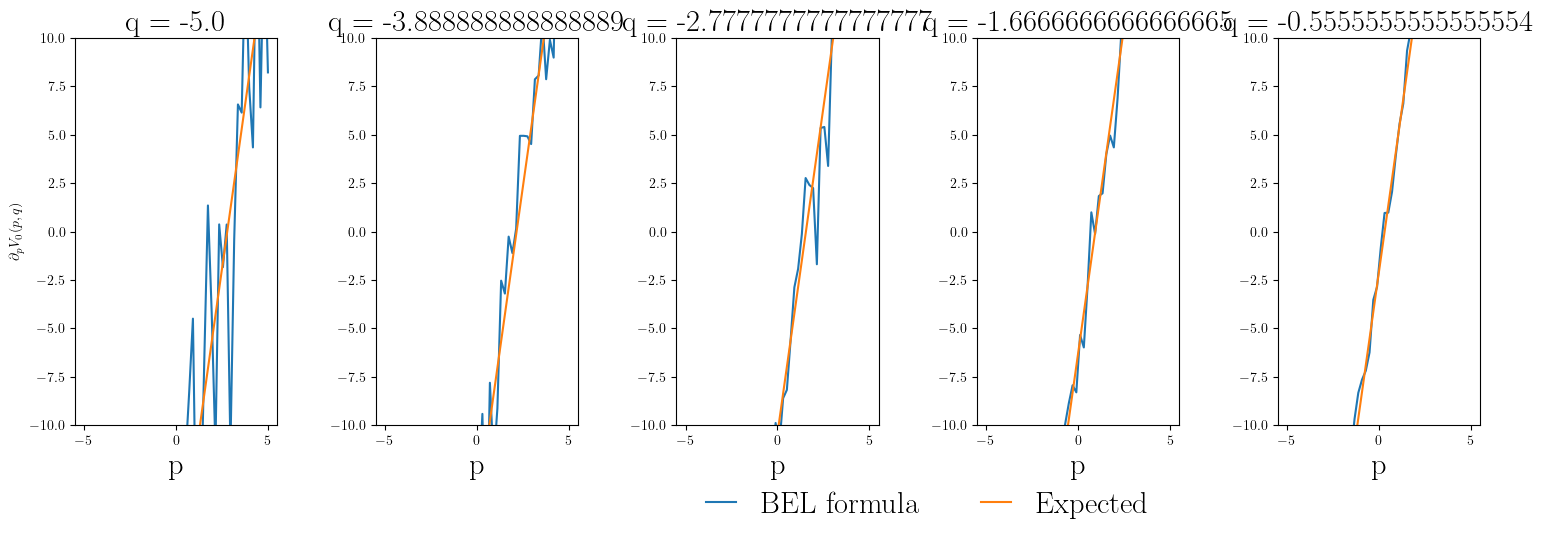

In [ ]:
fig, axs = plt.subplots(1,5)
fig.set_figheight(5)
fig.set_figwidth(15)

fontsize = 22
fontsizeticks = 18
fontsizetitles = 22

for idx in range(0,5):
  axs[idx].plot(p_init,dvtx_p[idx,:],label="BEL formula")
  axs[idx].plot(p_init,Dp_gauss_value(0,p_init,q_init[idx]),label="Expected")
  axs[idx].set_ylim((-10,10))
  axs[idx].set_xlabel("p",fontsize = fontsizetitles)
  axs[idx].set_title(f"q = {q_init[idx]}",fontsize = fontsizetitles,pad = 5)


axs[0].set_ylabel(r"$\partial_p V_0(p,q)$")
plt.legend(fontsize = fontsizetitles)
plt.xlabel("p",fontsize = fontsizetitles)
#plt.suptitle(r"Gradient of Value function", fontsize= fontsizetitles)
#plt.ylabel(r"$\partial_p V_T\ (p,1)$");

plt.tight_layout()
plt.legend(prop = {"size": fontsizetitles },
              handlelength=1,
              ncol = 4,
              bbox_to_anchor=(-0.5, -0.1),
              frameon = False)




In [ ]:
fig = plt.figure(figsize= (10,6))

plt.subplot(121)
plt.contour(Q,P,dvtx_p,cmap="Blues")
cbar1 = plt.colorbar(pad=0.)
#cbar2.set_ticklabels(fontsize=fontsizeticks)
plt.contour(Q,P,Dp_gauss_value(0,P,Q),cmap="Oranges")
cbar2 = plt.colorbar(pad=0.0,anchor=(1, 0.5))
cbar2.set_ticklabels([])
plt.xlabel("$q$",fontsize=fontsizetitles)
plt.ylabel("$p$",fontsize=fontsizetitles)
plt.gca().tick_params(axis='both', labelsize=fontsizeticks)


plt.subplot(122)
temp_out = np.multiply(dvtx_p,np.exp(-((P**2)/2)))/np.sqrt(2*np.pi)
dv_out = np.trapz(temp_out,p_init,axis=1)

plt.plot(q_init,dv_out/(epsilon/2),label="Monte Carlo w. BEL")
plt.plot(q_init,gauss_drift(0,q_init),label=r"Expected")
plt.xlabel("$q$",fontsize=fontsizetitles)
plt.ylabel("$\partial_q U(q)$",fontsize=fontsizetitles)
plt.gca().tick_params(axis='both', labelsize=fontsizeticks)

plt.tight_layout()
plt.legend(prop = {"size": fontsizetitles },
              handlelength=1,
              ncol = 4,
              bbox_to_anchor=(0.7, -0.1),
              frameon = False)
;

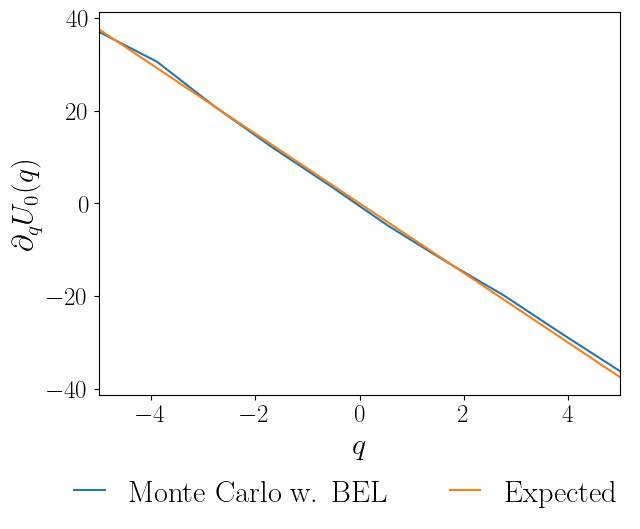

In [ ]:
#multiply be the joint distribution
temp_out = np.multiply(dvtx_p,np.exp(-((P**2)/2)))/np.sqrt(2*np.pi)
#temp_out1 = np.multiply(np.gradient(vtx,p_init,axis=1),np.exp(-((P**2)/2)))/np.sqrt(2*np.pi)
#temp_out2 = np.multiply(Dp_gauss_value(0,P,Q),np.exp(-((P**2)/2)))/np.sqrt(2*np.pi)

#integrate over p
dv_out = np.trapz(temp_out,p_init,axis=1)
#dv_out1 = np.trapz(temp_out1,p_init,axis=1)
#dv_out2 = np.trapz(temp_out2,p_init,axis=1)


plt.plot(q_init,-dv_out/(epsilon/2),label="Monte Carlo w. BEL")
plt.plot(q_init,-gauss_drift(0,q_init),label=r"Expected") #du
plt.xlabel("$q$",fontsize=fontsizetitles)
plt.ylabel("$\partial_q U_0(q)$",fontsize=fontsizetitles)
plt.gca().tick_params(axis='both', labelsize=fontsizeticks)

plt.xlim((-5,5))


plt.tight_layout()
plt.legend(prop = {"size": fontsizetitles },
              handlelength=1,
              ncol = 4,
              bbox_to_anchor=(1.05, -0.15),
              frameon = False)

plt.savefig("bel_gradient_kl_gauss.pdf",bbox_inches="tight")
plt.savefig("bel_gradient_kl_gauss.eps",bbox_inches="tight")

In [ ]:
vtx = np.nanmean(gauss_value_final(p_evo_UD_prev,q_evo_UD_prev) - (epsilon**2/4)*p_iota4,axis=0)
dvtx_p = np.nanmean(gauss_value_final(p_evo_UD_prev,q_evo_UD_prev)*p_iota2/((T-t)**2) - (epsilon**2/4)*p_iota3,axis=0)


#Machine learning Plots

This makes the Fig.5 of 2411.08518 from the results of "mcintegration_neural"

In [ ]:
df_nn = pd.DataFrame(pd.read_csv("entropy_nn_v2.csv"))#pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/overdamped_kl_results_v10.csv"))
df_driftnn = pd.DataFrame(pd.read_csv("entropy_nndrift_v3.csv"))#pd.DataFrame(pd.read_csv("drive/MyDrive/Colab Notebooks/overdamped_kl_results_v10.csv"))


In [ ]:
q_axis = np.linspace(-3,3)
p_final = np.exp(-(q_axis**2-1)**2/4)
pf_norm = np.trapz(p_final,q_axis)

fig_dist = plt.figure(figsize= (8,8))
plt.scatter(df_nn.x,df_nn.ptx,color=c1)
plt.plot(q_axis,p_final/pf_norm,color="orange",lw=3)
ax = plt.gca()
format_dist_axes(ax)
ax.set_ylim(-0.01,0.4)
ax.set_xlabel(r"$q$",fontsize=fontsizetitles)
ax.set_ylabel(r"$\mathrm{p}_{t_f}(q)$",fontsize=fontsizetitles)
plt.show()


In [ ]:
fontsizeticks = 18

#set up plots
#panel labels:
label_titles = ["(a)","(b)","(c)","(d)","(e)","(f)","(g)","(h)"]

#plot_titles = [f"$t = {plot_times[j]}$" for j in range(0,len(plot_times))]
#plot_titles = np.flip(plot_titles)

# Plotting the distributions -initialise the figure object & creates the gridspec
fig_nn = plt.figure(figsize=(15,10))
gs_nn = fig_nn.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1], height_ratios=[1, 1])


#function for plotting
def nn_plot(fig,plot_index,
                currtime,label):

  """
  Function that plots the scatter plot of the monte carlo approximation of the joint distribution

  input:
  - fig: the figure for plotting
  - plot_index: location of plot
  - time
  """

  #get the indices
  x_ind = int(np.floor(plot_index/4))
  y_ind = plot_index % 4

  #for first plot: plot the dirstibution
  if plot_index ==0:
    ax = fig.add_subplot(gs_nn[x_ind,y_ind])

    ax_inset = ax.inset_axes([0.3, 0.2, 1.4, 0.7])

    ax_inset.scatter(df_nn.x,df_nn.ptx,color=c1)
    ax_inset.plot(q_axis,p_final/pf_norm,color="orange",lw=3)
    format_dist_axes(ax_inset)
    ax_inset.set_ylim(-0.01,0.45)
    ax_inset.set_xlim(-3,3)

    ax_inset.set_xlabel(r"$q$",fontsize=fontsizetitles)
    ax_inset.set_ylabel(r"$\mathrm{p}_{t_f}(q)$",fontsize=fontsizetitles)

    #add letter label
    ax_inset.text(-2.75,0.39,label,fontsize = fontsizetitles,zorder = 200)
    ax.axis('off')
    #make it square
    #ax_inset.set_aspect('equal', adjustable='box')

  #all other plots, plot the drift at time "t"!
  else:

    #get data for time t
    ax = fig.add_subplot(gs_nn[x_ind,y_ind])
    ax.plot(df_driftnn[df_driftnn.t==currtime].x,df_driftnn[df_driftnn.t==currtime].ref_dutx,color="orange",lw=3)
    ax.plot(df_driftnn[df_driftnn.t==currtime].x,df_driftnn[df_driftnn.t==currtime].dutx,color=c1,lw=3)
    #ax.set_xlabel(r"$q$",fontsize=fontsizetitles)
    ax.set_ylim(-20,20)
    ax.set_xlim(-3,3)

    #add the letter label
    ax.text(-2.75,16,label,fontsize = fontsizetitles,zorder = 200)

    #get plot title
    ax.set_title(f"$t = {currtime}$", loc = "center", fontsize=fontsizetitles)

  if x_ind ==0:
    ax.set_xticklabels([])

  else:
    ax.set_xlabel(r"$q$",fontsize = fontsizetitles)

  if (((y_ind == 0) & (x_ind == 1)) or ((y_ind == 2) & (x_ind == 0))):

    #add y axis label
    ax.set_ylabel(r"$\partial U_{t}(q)$",fontsize = fontsizetitles)

  else:
    ax.set_yticklabels([])

  ax.tick_params(
        axis='both',          # changes apply to the x-axis
        which='both',
        labelsize = fontsizeticks)

<Figure size 1500x1000 with 0 Axes>

In [ ]:
nn_plot(fig_nn,0,0,"(a)")
nn_plot(fig_nn,2,0,"(b)")
nn_plot(fig_nn,3,0.04,"(c)")
nn_plot(fig_nn,4,0.08,"(d)")
nn_plot(fig_nn,5,0.12,"(e)")
nn_plot(fig_nn,6,0.16,"(f)")
nn_plot(fig_nn,7,0.2,"(g)")
fig_nn

In [ ]:

#add legend
blue_line = mlines.Line2D([], [],color=c1,lw=lw)
orange_line = mlines.Line2D([], [],color="orange",lw=lw)

legend = fig_nn.legend(handles=[blue_line,orange_line],
          labels = ["Neural Network Approx.","Caluya-Halder"],
          fontsize = fontsizetitles,
          frameon = False,
          handlelength = 1,
          ncols = 2,
          bbox_to_anchor=(1.2,0.25))
legend.set_bbox_to_anchor(bbox=(0.7,0.07))
